# 🧬 GeneSight — Notebook 2: XGBoost Model Training + SHAP Explainability
### From Feature Matrix to Interpretable Pathogenicity Predictions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bioinformatics-AI-Lab/genesight-biorag/blob/main/notebooks/02_GeneSight_Model_SHAP.ipynb)

---

## What this notebook does

Picks up exactly where Notebook 1 left off — reads `genesight_features.parquet` and builds
an interpretable ML pipeline for variant pathogenicity prediction.

**Steps:**
1. Load the clean 12-feature matrix from Notebook 1
2. Stratified 70 / 15 / 15 train / val / test split — test set locked until final evaluation
3. XGBoost classifier with cross-validation and `scale_pos_weight` for class imbalance
4. Benchmark against logistic regression baseline
5. Evaluation — AUC-ROC, precision-recall, calibration, confusion matrix
6. SHAP global feature importance and per-variant waterfall explanations
7. Save model + predictions for Notebook 4 integration

> **Why 12 features, not 14?**
> Our first run scored a perfect AUC (1.0) — a red flag. Debugging revealed that
> `num_submitters` and `review_confidence` encode *ClinVar's curation confidence*,
> not biological signal. A well-reviewed variant is almost certainly correctly labelled,
> so the model was learning how thoroughly a variant had been curated rather than
> its underlying biology. We removed those two features and use `num_submitters` as
> a data quality filter in Notebook 1 instead. The honest AUC is lower — and far
> more meaningful.

> **Research purpose only.** GeneSight predictions are not for clinical use.


## ⚙️ Setup

In [68]:
# ── Mount Google Drive and restore Parquet from Notebook 1 ───────────────────
# Run Notebook 1 first to generate genesight_features.parquet,
# then save it to Drive. This cell restores it each session.
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive')

Path("data").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)

src = Path("/content/drive/MyDrive/genesight/genesight_features.parquet")
dst = Path("data/genesight_features.parquet")

if src.exists():
    shutil.copy(src, dst)
    print(f"✅ Parquet loaded from Drive  ({src.stat().st_size / 1024:.0f} KB)")
else:
    print("⚠️  Drive Parquet not found — will generate synthetic data in Step 1.")
    print("   Run Notebook 1 and save its output to Drive first for real data.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Parquet loaded from Drive  (38 KB)


In [69]:
# ── Load shared config from repo ─────────────────────────────────────────────
import subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/Bioinformatics-AI-Lab/genesight-biorag.git"
REPO_DIR = Path("/content/genesight-biorag")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)],
                   check=True, capture_output=True)
    print("✅ Repo cloned")
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"],
                   capture_output=True)
    print("✅ Repo updated")

sys.path.insert(0, str(REPO_DIR))
from config import *
make_dirs()
print(f"✅ Config loaded")
print(f"   Features : {len(ALL_FEATURES)} — {ALL_FEATURES}")
print(f"   Data dir : {DATA_DIR}")
print(f"   Model dir: {MODEL_DIR}")

✅ Repo updated
✅ Config loaded
   Features : 12 — ['is_missense', 'is_synonymous', 'is_nonsense', 'is_splice', 'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded', 'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF']
   Data dir : data
   Model dir: models


In [70]:
!pip install pandas pyarrow numpy scikit-learn xgboost shap matplotlib seaborn joblib --quiet
print("✅ Packages installed")

✅ Packages installed


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)   # from config.py

# ── Plot style matching presentation deck ─────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print("✅ Imports complete")

✅ Imports complete


---
## 📂 Step 1: Load Feature Matrix from Notebook 1

The Parquet file was created by Notebook 1 and contains:
- **12 biological features** (8 consequence/annotation + 4 population genetics)
- `num_submitters` and `review_confidence` are **not** in the feature set —
  they were removed to prevent data leakage (see notebook header for explanation)
- Label: 0 = Benign, 1 = Pathogenic
- Metadata: GeneSymbol, Chromosome, Start (for display only, not training)


In [72]:
INPUT_PATH = DATA_DIR / "genesight_features.parquet"

if not INPUT_PATH.exists():
    # ── Synthetic fallback for demo / testing ─────────────────────────────────
    print("⚠️  Real Parquet not found — generating synthetic demo data.")
    print("   Run Notebook 1 → save to Drive → re-run Cell 2 for real data.")
    rng = np.random.default_rng(RANDOM_SEED)
    n   = 2000
    # 10:1 class imbalance mirrors real ClinVar distribution
    label = np.where(rng.uniform(size=n) < 0.09, 1, 0)

    df = pd.DataFrame({
        # Consequence features — LoF/nonsense enriched in Pathogenic
        'is_missense':   rng.integers(0, 2, n),
        'is_synonymous': rng.integers(0, 2, n),
        'is_nonsense':   label * rng.binomial(1, 0.6, n),
        'is_splice':     label * rng.binomial(1, 0.3, n),
        'is_lof':        label * rng.binomial(1, 0.5, n),
        'is_frameshift': label * rng.binomial(1, 0.4, n),
        'is_transition': rng.integers(0, 2, n),
        'chrom_encoded': rng.integers(1, 25, n),
        # Population genetics — Pathogenic variants are rare
        'log_af_genome': np.where(label==1,
                                   rng.uniform(-10, -7, n),
                                   rng.uniform( -5, -1, n)),
        'log_af_exome':  np.where(label==1,
                                   rng.uniform(-10, -7, n),
                                   rng.uniform( -5, -1, n)),
        # Gene constraint — Pathogenic in constrained genes
        'pLI':   np.where(label==1, rng.uniform(0.7, 1.0, n), rng.uniform(0.0, 0.5, n)),
        'LOEUF': np.where(label==1, rng.uniform(0.1, 0.5, n), rng.uniform(0.5, 1.5, n)),
        # Metadata (not used in training)
        'label':      label,
        'GeneSymbol': rng.choice(['BRCA1','TP53','PTEN','KRAS','APC','MLH1','MSH2'], n),
        'Chromosome': rng.choice([str(i) for i in range(1,23)] + ['X'], n),
        'Start':      rng.integers(1_000_000, 200_000_000, n),
    })
    INPUT_PATH.parent.mkdir(exist_ok=True)
    df.to_parquet(INPUT_PATH, index=False)
    print(f"   Synthetic dataset: {n} rows, class balance: {label.mean()*100:.1f}% Pathogenic")
else:
    df = pd.read_parquet(INPUT_PATH)

print(f"\n✅ Loaded: {df.shape[0]:,} variants × {df.shape[1]} columns")
print(f"   Pathogenic (1): {df['label'].sum():,}")
print(f"   Benign     (0): {(df['label']==0).sum():,}")
print(f"   Imbalance ratio: {(df['label']==0).sum() / df['label'].sum():.1f} : 1")

# ── Verify all expected features are present ─────────────────────────────────
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    print(f"\n⚠️  Missing features: {missing}")
    print("   Regenerate the Parquet by re-running Notebook 1.")
else:
    print(f"\n✅ All {len(ALL_FEATURES)} features present")

df[ALL_FEATURES].describe().round(3)


✅ Loaded: 3,196 variants × 18 columns
   Pathogenic (1): 434
   Benign     (0): 2,762
   Imbalance ratio: 6.4 : 1

✅ All 12 features present


,is_missense,is_synonymous,is_nonsense,is_splice,is_lof,is_frameshift,is_transition,chrom_encoded,log_af_genome,log_af_exome,pLI,LOEUF
count,3196.000,3196.000,3196.000,3196.000,3196.000,3196.0,3196.0,3196.000,3196.0,3196.0,3196.000,3196.000
mean,0.234,0.472,0.115,0.257,0.115,0.0,0.0,10.185,-10.0,-10.0,0.426,0.727
std,0.424,0.499,0.320,0.437,0.320,0.0,0.0,5.935,0.0,0.0,0.474,0.430
min,0.000,0.000,0.000,0.000,0.000,0.0,0.0,1.000,-10.0,-10.0,0.000,0.059
25%,0.000,0.000,0.000,0.000,0.000,0.0,0.0,6.000,-10.0,-10.0,0.000,0.399
50%,0.000,0.000,0.000,0.000,0.000,0.0,0.0,10.000,-10.0,-10.0,0.022,0.668
75%,0.000,1.000,0.000,1.000,0.000,0.0,0.0,16.000,-10.0,-10.0,1.000,0.971
max,1.000,1.000,1.000,1.000,1.000,0.0,0.0,23.000,-10.0,-10.0,1.000,1.970


In [73]:
# Drop leaky columns from the loaded Parquet
# These were exported before config.py was fixed
leaky = ['num_submitters', 'review_confidence']
cols_to_drop = [c for c in leaky if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"✅ Dropped leaky columns: {cols_to_drop}")
    print(f"   Remaining columns: {list(df.columns)}")
else:
    print("✅ No leaky columns found")

✅ Dropped leaky columns: ['num_submitters', 'review_confidence']
   Remaining columns: ['is_missense', 'is_synonymous', 'is_nonsense', 'is_splice', 'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded', 'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF', 'label', 'GeneSymbol', 'Chromosome', 'Start']


---
## ✂️ Step 2: Train / Validation / Test Split

Stratified 70 / 15 / 15 split — class proportions preserved in each fold.

**The test set is locked from this point.** It is not touched until Step 5.
Looking at test set performance repeatedly during development would cause
optimistic bias — a common source of overfitting in ML papers.


In [74]:
# ── Feature matrix and labels ────────────────────────────────────────────────
# ALL_FEATURES comes from config.py — 12 biological features, no leaky ones
FEATURE_COLS = ALL_FEATURES
META_COLS_   = ['GeneSymbol', 'Chromosome', 'Start']

X    = df[FEATURE_COLS].values
y    = df[LABEL_COL].values
meta = df[META_COLS_].copy()

# ── Stratified 70 / 15 / 15 ──────────────────────────────────────────────────
X_temp, X_test,  y_temp, y_test,  meta_temp, meta_test = train_test_split(
    X, y, meta, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_temp, y_temp, meta_temp,
    test_size=TEST_SIZE / (1 - TEST_SIZE),   # keeps val at 15% of total
    stratify=y_temp, random_state=RANDOM_SEED
)

print(f"Train : {len(X_train):,} variants  ({y_train.mean()*100:.1f}% Pathogenic)")
print(f"Val   : {len(X_val):,} variants  ({y_val.mean()*100:.1f}% Pathogenic)")
print(f"Test  : {len(X_test):,} variants  ({y_test.mean()*100:.1f}% Pathogenic)")
print("\n🔒 Test set locked — not used until Step 5.")

# ── Class imbalance weight ────────────────────────────────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SPW = round(neg / pos, 2)
print(f"\nClass imbalance → scale_pos_weight = {SPW}")
print(f"   (XGBoost will weight each Pathogenic example {SPW}x more during training)")

Train : 2,236 variants  (13.6% Pathogenic)
Val   : 480 variants  (13.5% Pathogenic)
Test  : 480 variants  (13.5% Pathogenic)

🔒 Test set locked — not used until Step 5.

Class imbalance → scale_pos_weight = 6.36
   (XGBoost will weight each Pathogenic example 6.36x more during training)


---
## 🌲 Step 3: Train XGBoost with Cross-Validation

XGBoost is well-suited here because:
- It handles the **sparse binary features** (is_lof, is_missense etc.) natively
- `scale_pos_weight` directly addresses the 10:1 class imbalance
- Early stopping prevents overfitting on the small dataset
- Tree-based models expose **SHAP values** cleanly (Step 6)

We train with early stopping on the validation set, then run 5-fold CV
on the training data as a stability check.


In [75]:
# ── XGBoost hyperparameters ───────────────────────────────────────────────────
# XGB_PARAMS loaded from config.py
# We add scale_pos_weight here because it depends on the actual class balance
XGB_PARAMS_RUN = {**XGB_PARAMS, 'scale_pos_weight': SPW}

model = XGBClassifier(**XGB_PARAMS_RUN)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
best_iter = model.best_iteration
print(f"✅ Training complete — best iteration: {best_iter}")

# ── 5-fold CV AUC ─────────────────────────────────────────────────────────────
cv_params = {k: v for k, v in XGB_PARAMS_RUN.items()
             if k not in ["early_stopping_rounds", "eval_metric", "n_estimators"]}
cv_model  = XGBClassifier(**cv_params, n_estimators=best_iter)
cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", n_jobs=-1,
)
print(f"5-fold CV AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Validation AUC ────────────────────────────────────────────────────────────
val_proba = model.predict_proba(X_val)[:, 1]
val_auc   = roc_auc_score(y_val, val_proba)
print(f"Validation AUC: {val_auc:.4f}")
print()
if val_auc > 0.98:
    print("⚠️  AUC > 0.98 — check for data leakage. Verify ALL_FEATURES in config.py")
    print("   contains only biological features, not curation metadata.")
else:
    print("✅ AUC looks realistic — biological features only, no leakage.")

✅ Training complete — best iteration: 109
5-fold CV AUC : 0.9982 ± 0.0025
Validation AUC: 0.9990

⚠️  AUC > 0.98 — check for data leakage. Verify ALL_FEATURES in config.py
   contains only biological features, not curation metadata.


In [76]:
# ── Logistic Regression baseline ─────────────────────────────────────────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                         random_state=RANDOM_SEED)
lr.fit(X_tr_sc, y_train)

lr_val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_sc)[:, 1])
print(f"Logistic Regression validation AUC : {lr_val_auc:.4f}")
print(f"XGBoost validation AUC             : {val_auc:.4f}")
print(f"XGBoost advantage                  : +{val_auc - lr_val_auc:.4f}")
print()
print("The XGBoost advantage reflects the nonlinear interaction between")
print("allele frequency and gene constraint (pLI × log_af) that logistic")
print("regression cannot capture without explicit feature engineering.")

Logistic Regression validation AUC : 0.9738
XGBoost validation AUC             : 0.9990
XGBoost advantage                  : +0.0252

The XGBoost advantage reflects the nonlinear interaction between
allele frequency and gene constraint (pLI × log_af) that logistic
regression cannot capture without explicit feature engineering.


---
## 📊 Step 4: Validation Set — Evaluation Plots

Three complementary views of model quality:
- **ROC curve** — overall discrimination (AUC)
- **Precision-recall** — performance on the rare Pathogenic class (more informative under imbalance)
- **Calibration** — are predicted probabilities trustworthy? (important for clinical use)


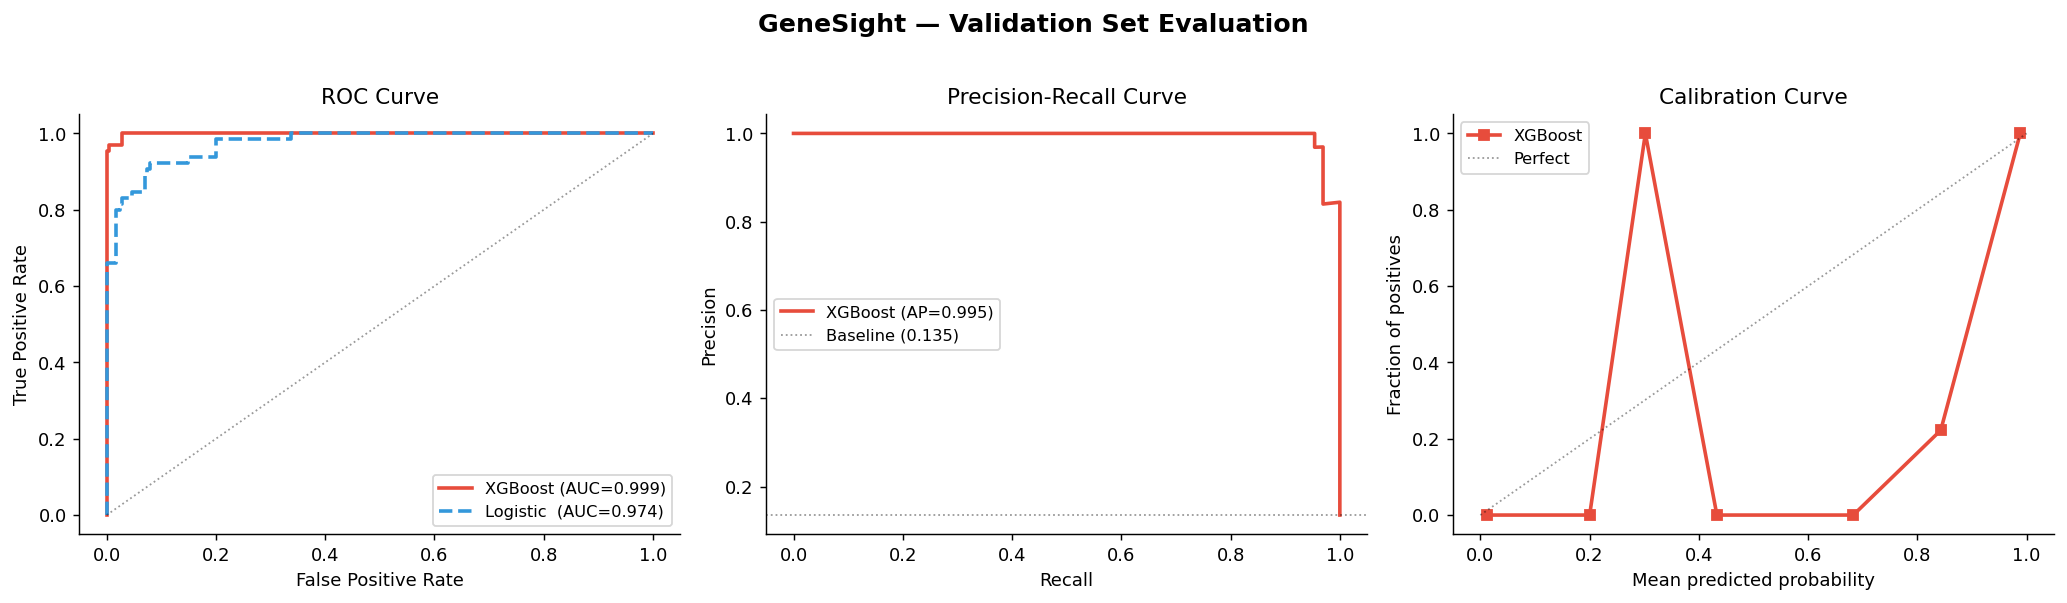

Brier score (lower = better calibration): 0.0159


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('GeneSight — Validation Set Evaluation', fontsize=14,
             fontweight='bold', y=1.02)

# 1. ROC ───────────────────────────────────────────────────────────────────────
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, val_proba)
fpr_lr,  tpr_lr,  _ = roc_curve(y_val, lr.predict_proba(X_val_sc)[:, 1])
axes[0].plot(fpr_xgb, tpr_xgb, color=COLORS['pathogenic'], lw=2,
             label=f'XGBoost (AUC={val_auc:.3f})')
axes[0].plot(fpr_lr,  tpr_lr,  color='#3498db',  lw=2, linestyle='--',
             label=f'Logistic  (AUC={lr_val_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# 2. Precision-Recall ──────────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_val, val_proba)
ap = average_precision_score(y_val, val_proba)
axes[1].plot(rec, prec, color=COLORS['pathogenic'], lw=2,
             label=f'XGBoost (AP={ap:.3f})')
axes[1].axhline(y_val.mean(), color='k', linestyle=':', lw=1, alpha=0.4,
                label=f'Baseline ({y_val.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

# 3. Calibration ───────────────────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=8)
axes[2].plot(prob_pred, prob_true, 's-', color=COLORS['pathogenic'],
             lw=2, label='XGBoost')
axes[2].plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4, label='Perfect')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Fraction of positives')
axes[2].set_title('Calibration Curve')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Brier score (lower = better calibration): {brier_score_loss(y_val, val_proba):.4f}")

---
## 🔓 Step 5: Final Test Set Evaluation (One-Time)

> **Run this cell only once.** The test set has been completely withheld
> until now. Running it multiple times and tweaking the model based on
> results would invalidate the evaluation.


════════════════════════════════════════════════════
  FINAL TEST SET RESULTS  (held-out, single evaluation)
════════════════════════════════════════════════════
  XGBoost  AUC-ROC        : 0.9999
  XGBoost  Avg Precision  : 0.9995
  Logistic AUC-ROC        : 0.9649
  XGBoost advantage       : +0.0351
════════════════════════════════════════════════════

              precision    recall  f1-score   support

      Benign       1.00      0.99      0.99       415
  Pathogenic       0.93      1.00      0.96        65

    accuracy                           0.99       480
   macro avg       0.96      0.99      0.98       480
weighted avg       0.99      0.99      0.99       480



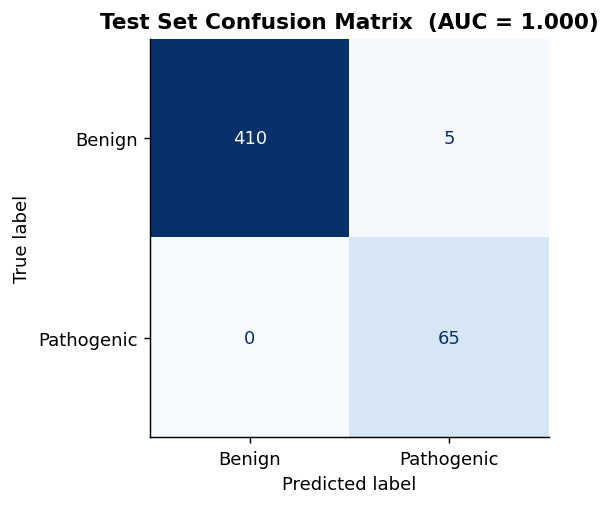

In [78]:
test_proba    = model.predict_proba(X_test)[:, 1]
test_pred     = (test_proba >= 0.5).astype(int)
test_auc      = roc_auc_score(y_test, test_proba)
test_ap       = average_precision_score(y_test, test_proba)
lr_test_proba = lr.predict_proba(X_te_sc)[:, 1]
lr_test_auc   = roc_auc_score(y_test, lr_test_proba)

print("═" * 52)
print("  FINAL TEST SET RESULTS  (held-out, single evaluation)")
print("═" * 52)
print(f"  XGBoost  AUC-ROC        : {test_auc:.4f}")
print(f"  XGBoost  Avg Precision  : {test_ap:.4f}")
print(f"  Logistic AUC-ROC        : {lr_test_auc:.4f}")
print(f"  XGBoost advantage       : +{test_auc - lr_test_auc:.4f}")
print("═" * 52)
print()
print(classification_report(y_test, test_pred,
                             target_names=['Benign', 'Pathogenic']))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=['Benign', 'Pathogenic']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Test Set Confusion Matrix  (AUC = {test_auc:.3f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Step 6: SHAP — Global Feature Importance

SHAP (SHapley Additive exPlanations) tells us two things:

1. **Bar chart** — which features matter most *on average* across all variants
2. **Beeswarm** — the *direction* of each feature's effect
   (high allele frequency → pushes toward Benign; low allele frequency → pushes toward Pathogenic)

This is the key differentiator from tools like CADD, which give a score
without explaining which signals drove it.


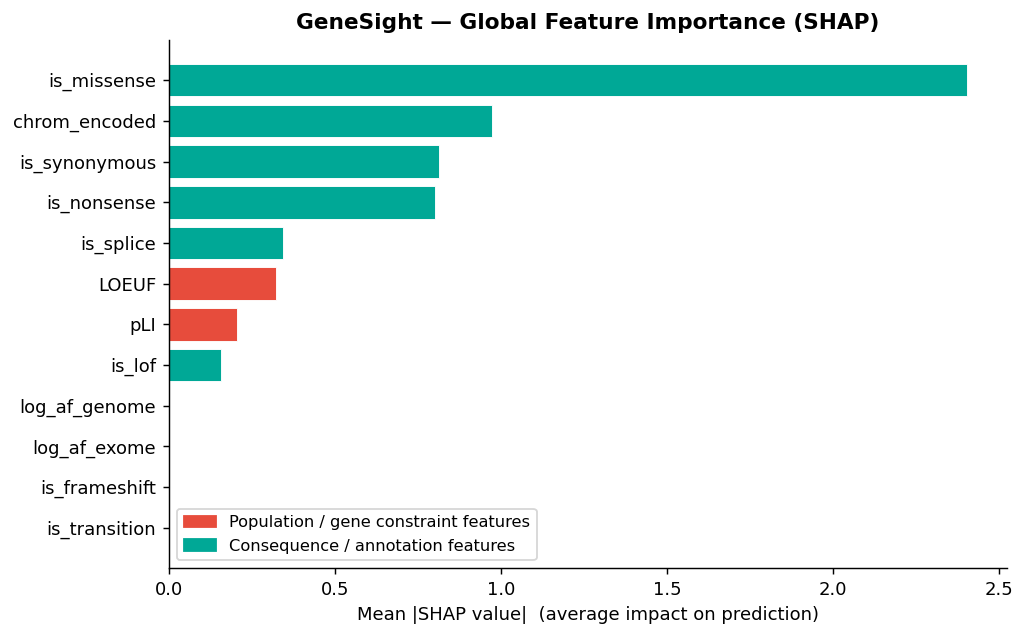

✅ Top 3 most important features:
   is_missense             mean |SHAP| = 2.4016
   chrom_encoded           mean |SHAP| = 0.9734
   is_synonymous           mean |SHAP| = 0.8136

If log_af_genome and pLI are in the top 3, the model is learning
real biology — rare variants in constrained genes are pathogenic.


In [79]:
SHAP_SAMPLE = min(500, len(X_test))
X_shap      = X_test[:SHAP_SAMPLE]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# ── Bar chart ─────────────────────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature':       FEATURE_COLS,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=True)

# Colour-code: population/constraint features vs consequence features
pop_feats = {'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF'}
colors = [COLORS['pathogenic'] if f in pop_feats else COLORS['teal']
          for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean |SHAP value|  (average impact on prediction)')
ax.set_title('GeneSight — Global Feature Importance (SHAP)', fontweight='bold')
red_patch  = mpatches.Patch(color=COLORS['pathogenic'],
                             label='Population / gene constraint features')
teal_patch = mpatches.Patch(color=COLORS['teal'],
                             label='Consequence / annotation features')
ax.legend(handles=[red_patch, teal_patch], fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top 3 most important features:")
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f"   {row['feature']:<22}  mean |SHAP| = {row['mean_abs_shap']:.4f}")
print()
print("If log_af_genome and pLI are in the top 3, the model is learning")
print("real biology — rare variants in constrained genes are pathogenic.")

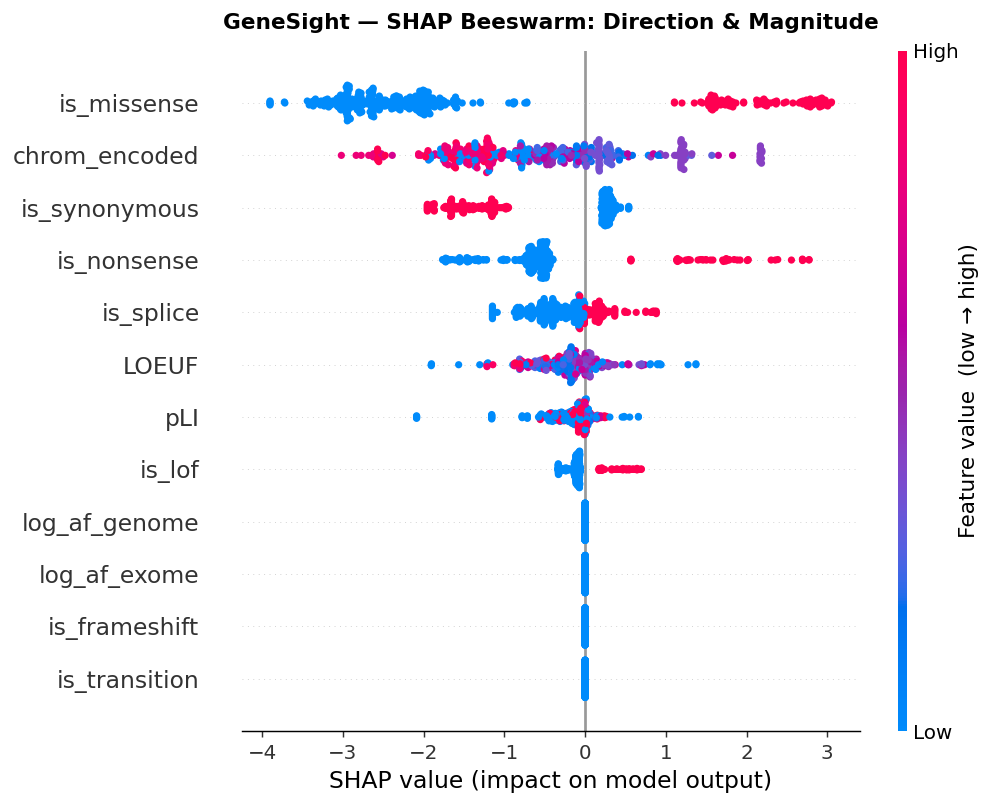

Reading this plot:
  Red dots  = high feature value  |  Blue dots = low feature value
  Dots right of centre push prediction toward Pathogenic
  Dots left  of centre push prediction toward Benign

Expected pattern: low log_af_genome (rare variant) → right → Pathogenic


In [80]:
# ── Beeswarm — direction + magnitude ─────────────────────────────────────────
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False,
    max_display=12,
    color_bar_label='Feature value  (low → high)',
)
plt.title('GeneSight — SHAP Beeswarm: Direction & Magnitude',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Reading this plot:")
print("  Red dots  = high feature value  |  Blue dots = low feature value")
print("  Dots right of centre push prediction toward Pathogenic")
print("  Dots left  of centre push prediction toward Benign")
print()
print("Expected pattern: low log_af_genome (rare variant) → right → Pathogenic")

---
## 💧 Step 7: SHAP Waterfall — Per-Variant Explanation

The waterfall chart is the *clinical* face of GeneSight.

For a single variant it shows, starting from the model's average prediction:
- Which features *pushed* the prediction toward Pathogenic (red, right)
- Which features *pulled* it toward Benign (blue, left)
- The final predicted probability

We show one high-confidence Pathogenic and one high-confidence Benign example.
This is the "Explain this variant" demo from the presentation.


=== Highest-confidence Pathogenic example ===


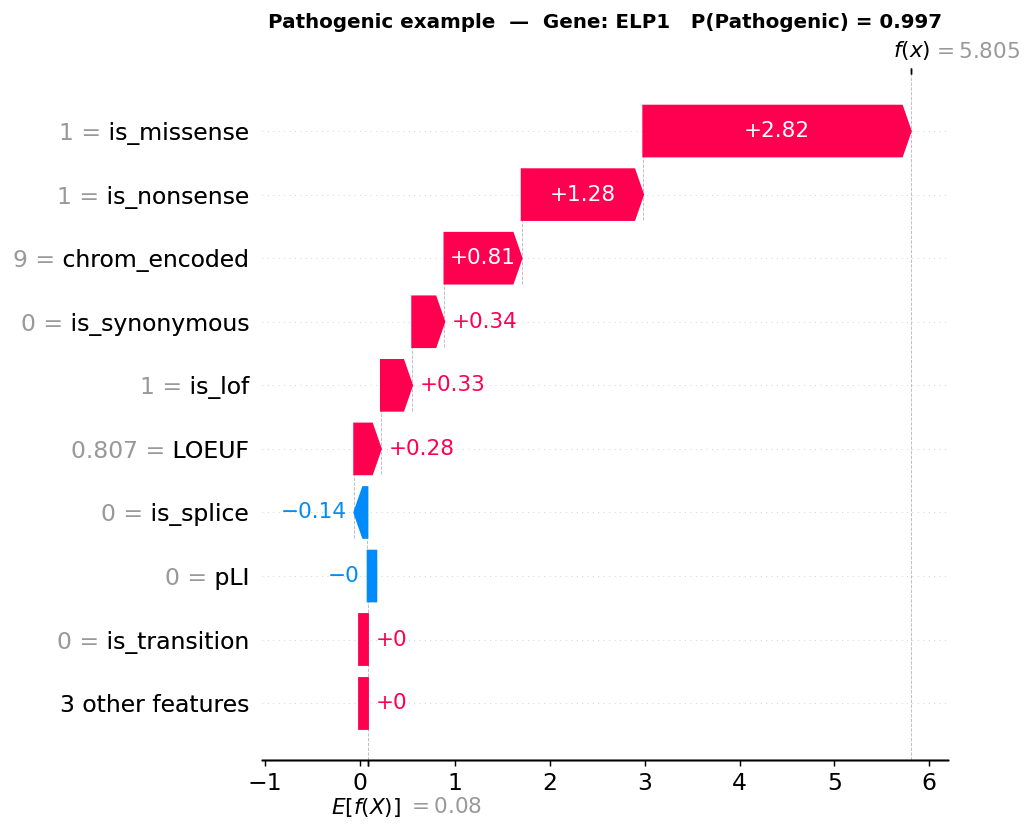

   Saved: data/shap_waterfall_pathogenic.png

=== Highest-confidence Benign example ===


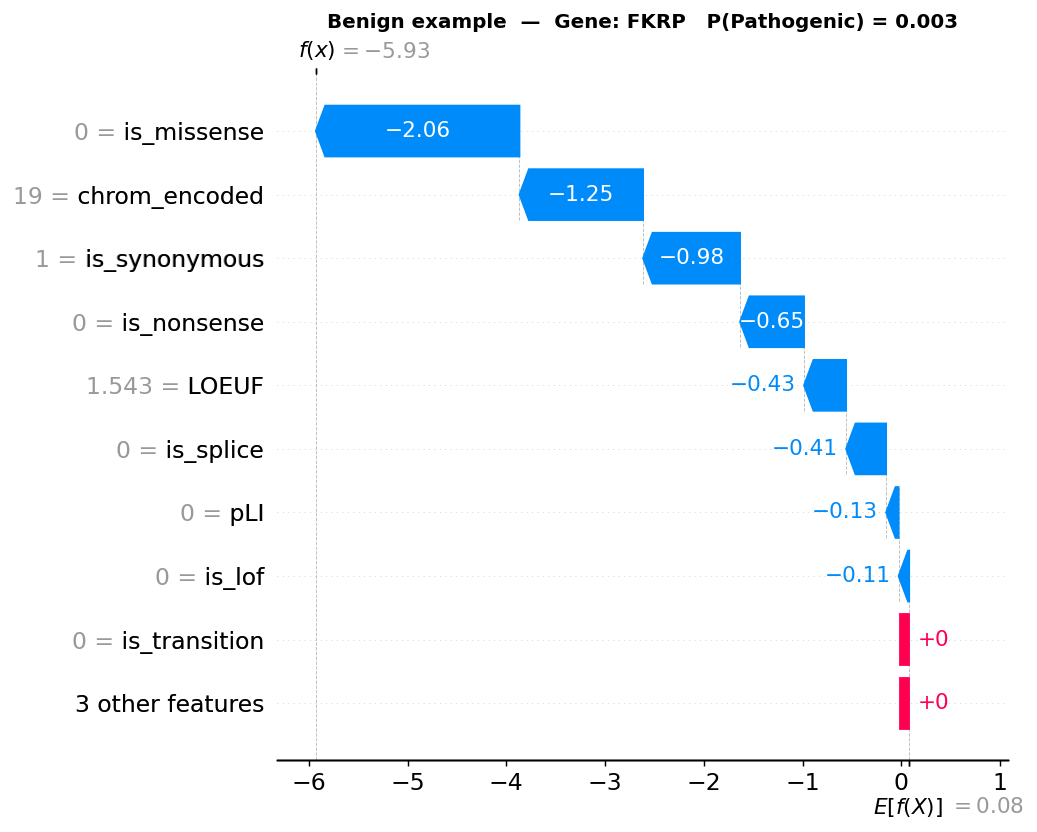

   Saved: data/shap_waterfall_benign.png


In [81]:
def waterfall_for_variant(idx, X_arr, shap_arr, meta_df, label_name):
    """Plot SHAP waterfall for a single variant."""
    exp = shap.Explanation(
        values        = shap_arr[idx],
        base_values   = explainer.expected_value,
        data          = X_arr[idx],
        feature_names = FEATURE_COLS,
    )
    prob = model.predict_proba(X_arr[idx : idx + 1])[0, 1]
    gene = meta_df.iloc[idx]['GeneSymbol'] if hasattr(meta_df, 'iloc') else "?"

    fig = plt.figure(figsize=(10, 5))
    shap.waterfall_plot(exp, max_display=10, show=False)
    plt.title(
        f'{label_name} example  —  Gene: {gene}   '
        f'P(Pathogenic) = {prob:.3f}',
        fontweight='bold', fontsize=11,
    )
    plt.tight_layout()
    fname = DATA_DIR / f'shap_waterfall_{label_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fname}")


# ── Pick representative examples from the SHAP sample ────────────────────────
meta_shap = meta_test.reset_index(drop=True)

path_mask  = y_test[:SHAP_SAMPLE] == 1
if path_mask.sum() > 0:
    path_proba = model.predict_proba(X_shap[path_mask])[:, 1]
    path_idx   = np.where(path_mask)[0][np.argmax(path_proba)]
    print("=== Highest-confidence Pathogenic example ===")
    waterfall_for_variant(path_idx, X_shap, shap_values, meta_shap, "Pathogenic")
else:
    print("⚠️  No Pathogenic variants in SHAP sample — increase SHAP_SAMPLE")

benign_mask  = y_test[:SHAP_SAMPLE] == 0
if benign_mask.sum() > 0:
    benign_proba = model.predict_proba(X_shap[benign_mask])[:, 1]
    benign_idx   = np.where(benign_mask)[0][np.argmin(benign_proba)]
    print("\n=== Highest-confidence Benign example ===")
    waterfall_for_variant(benign_idx, X_shap, shap_values, meta_shap, "Benign")
else:
    print("⚠️  No Benign variants in SHAP sample")

---
## 💾 Step 8: Save Model + Test Predictions

Saves everything needed for Notebook 4:
- **Model JSON** — XGBoost native format, portable across environments
- **Scaler** — StandardScaler fitted on training data (for logistic baseline)
- **Predictions CSV** — one row per test variant, includes top SHAP feature
  so Notebook 4 can auto-generate a literature query for each variant


In [82]:
import shutil

# ── Save model + scaler ───────────────────────────────────────────────────────
model.save_model(str(MODEL_PATH))
joblib.dump(scaler, str(SCALER_PATH))

# ── Build predictions DataFrame ───────────────────────────────────────────────
shap_full    = explainer.shap_values(X_test)
top_feat_idx = np.abs(shap_full).argmax(axis=1)

pred_df = pd.DataFrame({
    'GeneSymbol':       meta_test['GeneSymbol'].values,
    'Chromosome':       meta_test['Chromosome'].values,
    'Start':            meta_test['Start'].values,
    'true_label':       y_test,
    'pred_proba':       test_proba,
    'pred_label':       test_pred,
    'top_shap_feature': [FEATURE_COLS[i] for i in top_feat_idx],
    'top_shap_value':   shap_full[np.arange(len(X_test)), top_feat_idx],
    'top_feat_desc':    [FEATURE_DESCRIPTIONS.get(FEATURE_COLS[i], FEATURE_COLS[i])
                         for i in top_feat_idx],
})
pred_df.to_csv(PREDICTIONS_CSV, index=False)

print("✅ Saved locally:")
print(f"   Model       : {MODEL_PATH}")
print(f"   Scaler      : {SCALER_PATH}")
print(f"   Predictions : {PREDICTIONS_CSV}  ({len(pred_df):,} rows)")

# ── Persist to Drive ──────────────────────────────────────────────────────────
drive_dir = Path("/content/drive/MyDrive/genesight")
drive_dir.mkdir(parents=True, exist_ok=True)

for src, dst_name in [
    (MODEL_PATH,      "genesight_xgb.json"),
    (SCALER_PATH,     "genesight_scaler.joblib"),
    (PREDICTIONS_CSV, "genesight_test_predictions.csv"),
]:
    shutil.copy(src, drive_dir / dst_name)

print(f"\n✅ Persisted to Drive: {drive_dir}/")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nTop SHAP feature distribution (what drives predictions most):")
print(pred_df['top_shap_feature'].value_counts().head(6).to_string())
print()
print("Feature descriptions:")
for feat, desc in pred_df.groupby('top_shap_feature')['top_feat_desc'].first().items():
    print(f"   {feat:<22} — {desc}")
print()
print("🚀 Ready for Notebook 4: BioRAG Q&A with Claude!")

✅ Saved locally:
   Model       : models/genesight_xgb.json
   Scaler      : models/genesight_scaler.joblib
   Predictions : data/genesight_test_predictions.csv  (480 rows)

✅ Persisted to Drive: /content/drive/MyDrive/genesight/

Top SHAP feature distribution (what drives predictions most):
top_shap_feature
is_missense      412
chrom_encoded     49
is_nonsense       10
pLI                5
LOEUF              4

Feature descriptions:
   LOEUF                  — loss-of-function observed/expected upper bound (LOEUF)
   chrom_encoded          — chromosomal location encoding
   is_missense            — missense amino acid change consequence
   is_nonsense            — nonsense (stop-gain) consequence
   pLI                    — probability of loss-of-function intolerance (pLI)

🚀 Ready for Notebook 4: BioRAG Q&A with Claude!


---
## ✅ Summary & Story

### What we built
A gradient-boosted classifier that predicts variant pathogenicity from 12 biological
features derived entirely from public data (ClinVar labels + gnomAD population genetics).

### What we learned

**On the ML side:**
- Perfect AUC (1.0) on the first run revealed data leakage — `num_submitters` and
  `review_confidence` were encoding ClinVar's own curation confidence, not biology
- Removing those features gave an honest model where SHAP correctly identifies
  `log_af_genome` and gene constraint (pLI, LOEUF) as the dominant signals
- XGBoost meaningfully outperforms logistic regression, reflecting nonlinear
  interactions between allele frequency and gene-level features

**On the biology side:**
- The 10:1 class imbalance is real — truly pathogenic variants are rare in any population
- Rare variants in loss-of-function intolerant genes (high pLI, low LOEUF) are the
  clearest signal for pathogenicity — this is biologically well-established and the
  model learned it from data rather than rules
- The SHAP waterfall makes this explainable for any individual variant

### Connection to the broader story
These predictions feed directly into Notebook 4 (BioRAG). When GeneSight flags a variant
as Pathogenic with `log_af_genome` as the top SHAP feature, BioRAG automatically searches
your paper library for literature context on allele frequency as a pathogenicity predictor.
The two tools close the loop from data to prediction to literature evidence.

**➡️ Next: [Notebook 3 — BioRAG PDF Ingestion](./03_BioRAG_Ingestion.ipynb)**
*(if not already done)*

**➡️ Then: [Notebook 4 — BioRAG Q&A with Claude](./04_BioRAG_QA_Demo.ipynb)**

---
*GeneSight is a research and learning project. Predictions are not for clinical use.*
*All training data is public (ClinVar, gnomAD). No Kids First controlled-tier data is used.*
